# Extension 1 — Dynamic misspecification: VARMA(4,1) DGP (Ch. 4)

Stress-tests the Ch. 3 baseline ranking under **dynamic misspecification**. The DGP augments the baseline with a first-order moving-average term,
$$ y_t = \sum_{i=1}^4 A_i y_{t-i} + u_t + \Theta u_{t-1}, \qquad \Theta=\tau I_2,\quad u_t=B\varepsilon_t,\quad \varepsilon_t\sim\mathcal N(0,I_2), $$
with misspecification strength $\tau\in\{0.1,0.3,0.6\}$ ($\tau=0$ nests the baseline VAR(4)). The lag matrices $A_i$ and impact matrix $B$ are inherited from the baseline, so **all** variation is the MA component.

The VARMA is invertible, so it admits a VAR($\infty$) representation: a high-order VAR($q$) can approximate it, the equal-lag **VAR(4)** cannot (it carries an asymptotic bias that does not vanish with $T$), and **LP(4)** is robust by construction \[Montiel Olea et al.\]. Estimators (fixed **LP(4)** and the **VAR($q$) sweep**, $q=1\ldots p+H-1$) are applied **unchanged**; the estimand is the true VARMA structural IRF $\theta_h=(\Phi_h B)[1,1]$, computed analytically per $\tau$.

In [1]:
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

from mcsim.dgp import (VARSpec, VARMASpec, simulate_varma, varma_irf,
                       scale_to_persistence, spectral_radius)
from mcsim.estimators import estimate_lp_irf, estimate_var_irf, fit_var_ols
from mcsim.simulation import MCConfig, run

## 0. Set up model parameters

In [2]:
# Define the persistence scenario to run. Can be "LOW" (rho = 0.5), "MID" (rho = 0.7), "High" (rho = 0.95)
Scenario = "MID"

In [3]:
SEED = 42                                            # master RNG seed for all stochastic processes
P = 4
H= 20
RHO_SCENARIO = {"LOW": 0.5, "MID": 0.7, "HIGH": 0.95}
RHO = RHO_SCENARIO[Scenario]                                          # Rho in {0.5, 0.7, 0.95}

T = [100, 250, 500]
TAUS = [0.0, 0.1, 0.3, 0.6]    # MA misspecification strength (tau=0 nests baseline VAR(4))
T_SHOW = 250                     # sample size used for the per-tau diagnostic panels

M  = np.array([[0.50, 0.10], [0.10, 0.50]])      # symmetric, positive -> real, decaying
A0 = np.array([M, 0.4 * M, 0.2 * M, 0.1 * M])     # VAR(4): geometrically decaying lag matrices
B  = np.array([[1.0, 0.0], [0.5, 1.0]])           # recursive (lower-triangular) impact matrix
A_RHO = scale_to_persistence(A0, RHO)             # AR part scaled to target persistence; shared across tau

# VARMA(4,1) with Theta_1 = tau * I_2; tau=0 reproduces the baseline VAR(4) exactly.
DGPS = {tt: VARMASpec(A=A_RHO, Theta=np.array([tt * np.eye(2)]), B=B) for tt in TAUS}
print("AR spectral radius (persistence):", round(spectral_radius(A_RHO), 3),
      "| MA(1) root modulus 1/tau > 1 for tau<1 -> invertible (VAR-infinity exists)")

N_REPS = 5000  # nr of MC reps

AR spectral radius (persistence): 0.7 | MA(1) root modulus 1/tau > 1 for tau<1 -> invertible (VAR-infinity exists)


The true structural estimand $\theta_h=(\Phi_h B)[1,1]$ for each $\tau$. The MA term $\Theta u_{t-1}$ injects extra **short-horizon** propagation that lifts the early-horizon IRF, so as $\tau$ grows the response peaks higher near $h=1$ before decaying; $\tau=0$ recovers the baseline VAR(4).

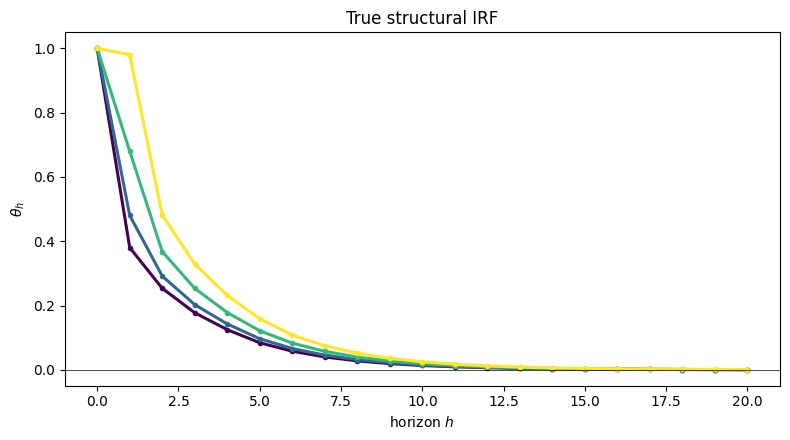

In [4]:
# True structural IRFs (no estimation) for each misspecification strength.
# Under VARMA(4,1) the MA term injects extra short-horizon propagation that lifts the
# early-horizon estimand; tau=0 nests the baseline VAR(4).
hgrid = np.arange(H + 1)
truth_byTau = {tt: varma_irf(DGPS[tt], H) for tt in TAUS}
ctau = {tt: plt.cm.viridis(i / max(len(TAUS) - 1, 1)) for i, tt in enumerate(TAUS)}

fig, ax = plt.subplots(figsize=(8, 4.5))
for tt in TAUS:
    lab = "τ=0  (baseline VAR(4))" if tt == 0 else f"τ={tt}"
    ax.plot(hgrid, truth_byTau[tt], "o-", lw=2.2, ms=3, color=ctau[tt], label=lab)
ax.axhline(0, color="k", lw=0.5)
ax.set_title("True structural IRF")
ax.set_xlabel("horizon $h$"); ax.set_ylabel(r"$\theta_h$")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_IRF_rho={RHO}.png")
plt.show()

## 2. Monte Carlo — LP(4) + VAR(q) sweep × misspecification × sample size

The three-way design of Ch. 4: for each $\tau\in\{0,0.1,0.3,0.6\}$ and $T\in\{100,250,500\}$ we run the fixed **LP(4)** and the full **VAR(q) sweep** ($q=1\ldots23$) on VARMA-generated data, **without modification**. The estimand is $T$-independent but **$\tau$-dependent** (`truth_byTau`). Raw stacks land in `results[(τ,T)]` and horizon-wise RMSE in `rmse[(τ,T)]`.

In [5]:
VAR_ORDERS = list(range(1, P + H))                  # 1, 2, ..., 22, 23

estimators = {"LP(4)": partial(estimate_lp_irf, p=P, horizon=H)}
estimators.update({f"VAR({q})": partial(estimate_var_irf, p=q, horizon=H) for q in VAR_ORDERS})


def varma_dgp(rng, Tlen, spec):
    return simulate_varma(spec, Tlen, rng)


results, rmse = {}, {}                               # keyed by (tau, T)
for tt in TAUS:
    truth = truth_byTau[tt]                        # estimand depends on tau
    for Tval in T:
        cfg = MCConfig(n_reps=N_REPS, T=Tval, horizon=H, seed=SEED, n_jobs=-1,
                       progress=True, estimators=estimators)
        res = run(partial(varma_dgp, spec=DGPS[tt]), cfg)
        results[(tt, Tval)] = res
        rmse[(tt, Tval)] = {nm: np.sqrt(np.nanmean((st - truth) ** 2, axis=0))
                            for nm, st in res["irfs"].items()}
        fails = {k: v for k, v in res["n_failures"].items() if v}
        print(f"tau={tt:<4} T={Tval:>4}: done  |  failures: {fails or 'none'}")

MC reps: 100%|██████████| 5000/5000 [00:03<00:00, 1299.89it/s]


tau=0.0  T= 100: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:05<00:00, 974.47it/s] 


tau=0.0  T= 250: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:06<00:00, 748.67it/s]


...

tau=0.6  T= 100: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:05<00:00, 892.31it/s] 


tau=0.6  T= 250: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:07<00:00, 680.46it/s]


tau=0.6  T= 500: done  |  failures: none


## 3. RMSE comparison: does the ranking survive misspecification?

The **complexity frontier** (horizon-averaged RMSE vs VAR order) at $T=250$, one curve per $\tau$, with LP(4) as a same-colour dashed reference. As $\tau$ grows the equal-lag (VAR(4)) end of the frontier should lift — four lags cannot fit the MA dynamics — while higher-order VARs and LP(4) absorb it. The table reports every $(\tau,T)$ cell.

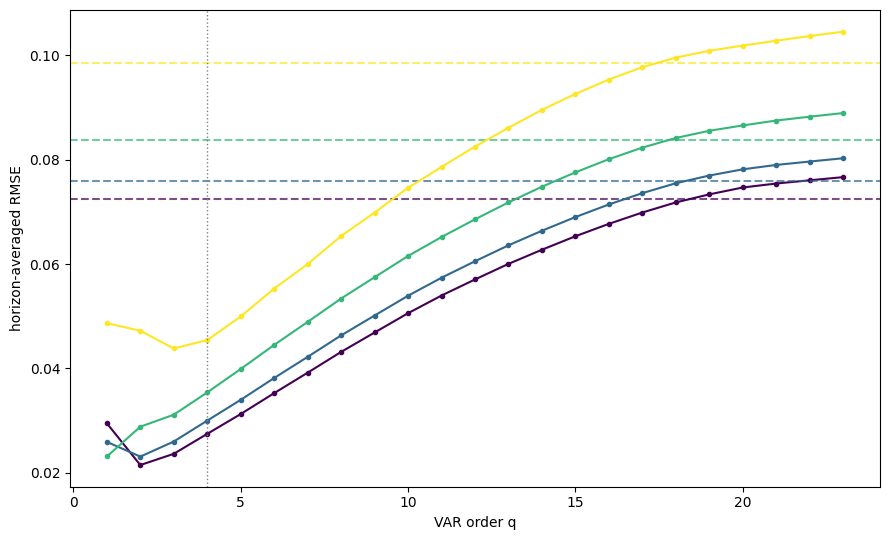

   tau     T    LP(4)   VAR(4)        bestVAR   LP-VAR4
--------------------------------------------------------
   0.0   100    0.123    0.045   VAR(2)=0.032    +0.078
   0.0   250    0.072    0.027   VAR(2)=0.021    +0.045
   0.0   500    0.050    0.019   VAR(3)=0.016    +0.032
   0.1   100    0.129    0.049   VAR(1)=0.033    +0.079
   0.1   250    0.076    0.030   VAR(2)=0.023    +0.046
   0.1   500    0.053    0.021   VAR(2)=0.017    +0.032
   0.3   100    0.142    0.059   VAR(1)=0.035    +0.084
   0.3   250    0.084    0.035   VAR(1)=0.023    +0.048
   0.3   500    0.058    0.024   VAR(1)=0.017    +0.034
   0.6   100    0.168    0.075   VAR(1)=0.059    +0.093
   0.6   250    0.099    0.045   VAR(3)=0.044    +0.053
   0.6   500    0.068    0.032   VAR(4)=0.032    +0.036
(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)


In [6]:
# (1) complexity frontier per tau, at T_SHOW
fig, ax = plt.subplots(figsize=(9, 5.5))
for tt in TAUS:
    rm = rmse[(tt, T_SHOW)]
    avg_var = [np.mean(rm[f"VAR({q})"]) for q in VAR_ORDERS]
    lab = "τ=0 (baseline)" if tt == 0 else f"τ={tt}"
    ax.plot(VAR_ORDERS, avg_var, "o-", ms=3, color=ctau[tt], label=lab)
    ax.axhline(np.mean(rm["LP(4)"]), ls="--", color=ctau[tt], alpha=0.7)
ax.axvline(4, color="gray", ls=":", lw=1)
# ax.set_title(f"Complexity frontier across τ  (T={T_SHOW};  solid = VAR(q), dashed = LP(4), same color), ρ={RHO} ({Scenario})")
ax.set_xlabel("VAR order q"); ax.set_ylabel("horizon-averaged RMSE")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_COMPLEXITY_FRONTIER_rho={RHO}_T={T_SHOW}.png")
plt.show()

# (2) full (tau, T) summary table
print(f"{'tau':>6} {'T':>5} {'LP(4)':>8} {'VAR(4)':>8} {'bestVAR':>14} {'LP-VAR4':>9}")
print("-" * 56)
for tt in TAUS:
    for Tval in T:
        rm = rmse[(tt, Tval)]
        lp = float(np.mean(rm["LP(4)"])); v4 = float(np.mean(rm["VAR(4)"]))
        avgs = {q: float(np.mean(rm[f"VAR({q})"])) for q in VAR_ORDERS}
        bq = min(avgs, key=avgs.get)
        print(f"{tt:>6} {Tval:>5} {lp:8.3f} {v4:8.3f} {f'VAR({bq})={avgs[bq]:.3f}':>14} {lp - v4:+9.3f}")
print("(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)")

## 5. Point-estimation metrics under misspecification (Ch. 3 metrics)

Same per-horizon **bias / variance / MSE / RMSE** decomposition as the baseline, now at the strongest misspecification $\tau=0.6$, $T=250$. Unlike the correctly-specified baseline (VAR bias ≈ 0), here low-order VARs carry genuine bias, so $\mathrm{MSE}_h=\mathrm{Bias}_h^2+\mathrm{Var}_h$ has a non-negligible squared-bias component at short horizons. $\mathrm{MCSE}(\widehat{\mathrm{Bias}}_h)=\sqrt{\widehat{\mathrm{Var}}_h/B}$ bounds simulation noise.

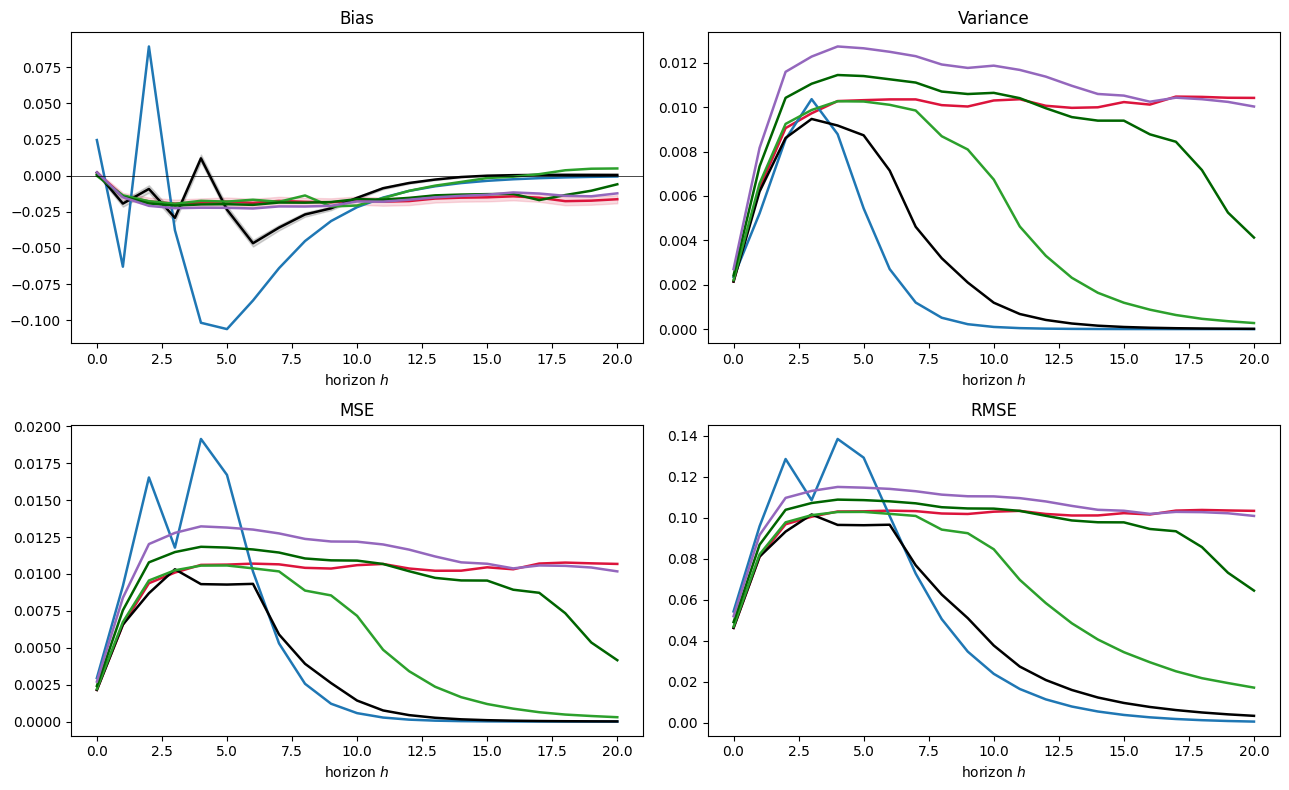

τ=0.6, T=250, B=5000   |   typical MCSE(bias) ~ 0.0007


h=1             h=8            h=20        
           bias    RMSE    bias    RMSE    bias    RMSE
LP(4)   -0.0141  0.0809 -0.0181  0.1021 -0.0163  0.1033
VAR(2)  -0.0630  0.0958 -0.0453  0.0506 -0.0006  0.0007
VAR(4)  -0.0193  0.0811 -0.0269  0.0626  0.0005  0.0035
VAR(8)  -0.0136  0.0821 -0.0137  0.0942  0.0049  0.0172
VAR(16) -0.0146  0.0868 -0.0187  0.1051 -0.0060  0.0645
VAR(23) -0.0150  0.0916 -0.0214  0.1112 -0.0123  0.1009

In [7]:
import pandas as pd
from IPython.display import display


def metrics(stack, truth):
    """Per-horizon Ch. 3 point metrics for a (B, H+1) stack of IRF estimates."""
    B = int(np.sum(~np.isnan(stack[:, 0])))
    mean = np.nanmean(stack, axis=0)
    bias = mean - truth
    var = np.nanvar(stack, axis=0, ddof=1)
    mse = np.nanmean((stack - truth) ** 2, axis=0)
    return dict(bias=bias, var=var, mse=mse, rmse=np.sqrt(mse),
                mcse_bias=np.sqrt(var / B), B=B)


TAU_SHOW, Tval = 0.6, T_SHOW                          # strongest misspecification cell
truth = truth_byTau[TAU_SHOW]
sel = ["LP(4)", "VAR(2)", "VAR(4)", "VAR(8)", "VAR(16)", "VAR(23)"]
colm = {"LP(4)": "crimson", "VAR(2)": "tab:blue", "VAR(4)": "black",
        "VAR(8)": "tab:green", "VAR(16)": "darkgreen", "VAR(23)": "tab:purple"}
m = {nm: metrics(results[(TAU_SHOW, Tval)]["irfs"][nm], truth) for nm in sel}

fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for nm in sel:
    ax[0, 0].plot(hgrid, m[nm]["bias"], color=colm[nm], lw=1.8, label=nm)
    ax[0, 1].plot(hgrid, m[nm]["var"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 0].plot(hgrid, m[nm]["mse"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 1].plot(hgrid, m[nm]["rmse"], color=colm[nm], lw=1.8, label=nm)
for nm in ("LP(4)", "VAR(4)"):                       # MCSE band on bias (sim. uncertainty)
    lo, hi = m[nm]["bias"] - 1.96 * m[nm]["mcse_bias"], m[nm]["bias"] + 1.96 * m[nm]["mcse_bias"]
    ax[0, 0].fill_between(hgrid, lo, hi, color=colm[nm], alpha=0.15)
ax[0, 0].axhline(0, color="k", lw=0.5)
ax[0, 0].set_title("Bias")
ax[0, 1].set_title("Variance"); ax[1, 0].set_title("MSE"); ax[1, 1].set_title("RMSE")
for a in ax.ravel():
    a.set_xlabel("horizon $h$")
# fig.suptitle(f"Point metrics under misspecification, τ={TAU_SHOW}, T={Tval}, B={N_REPS}, ρ={RHO} ({Scenario})",
#             fontweight="bold")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_POINT_ESTIMATION_rho={RHO}_T={T_SHOW}_B=5000_tau={TAU_SHOW}.png")
plt.show()

# compact table: bias and RMSE at selected horizons
report = [1, 8, 20]
rows = {nm: {(f"h={h}", k): m[nm][{"bias": "bias", "RMSE": "rmse"}[k]][h]
             for h in report for k in ("bias", "RMSE")} for nm in sel}
tab = pd.DataFrame(rows).T
tab.columns = pd.MultiIndex.from_tuples(tab.columns)
print(f"τ={TAU_SHOW}, T={Tval}, B={N_REPS}   |   typical MCSE(bias) ~ "
      f"{np.mean([m['VAR(4)']['mcse_bias'][h] for h in report]):.4f}")
display(tab.round(4))

## 6. Inference — coverage under misspecification (Ch. 3)

Coverage of nominal 95% CIs for the **true** VARMA $\theta_h$, at the strongest misspecification $\tau=0.6$ (matching the point-estimation panel), in the **same format as the baseline**: the misspecified equal-lag **VAR(4)**, the high-order **VAR(23)**, and the robust **LP(4)**.

* **VAR(q): delta method** — propagates reduced-form coefficient uncertainty through $\theta_h=\hat\Psi_h\hat B e_1$ (variance only; $B$ held fixed).
* **LP(4): HC1-robust SE** of the shock coefficient.

A variance-only CI ignores bias, so under misspecification it can only *miss* the truth more often as bias grows. The right panel validates the VAR(4) delta-method SE against the empirical sampling SD of $\hat\theta_h$ — close agreement means the under-coverage is a *bias* effect, not a broken SE.

coverage MC τ=0.6: 100%|██████████| 5000/5000 [00:23<00:00, 214.62it/s]


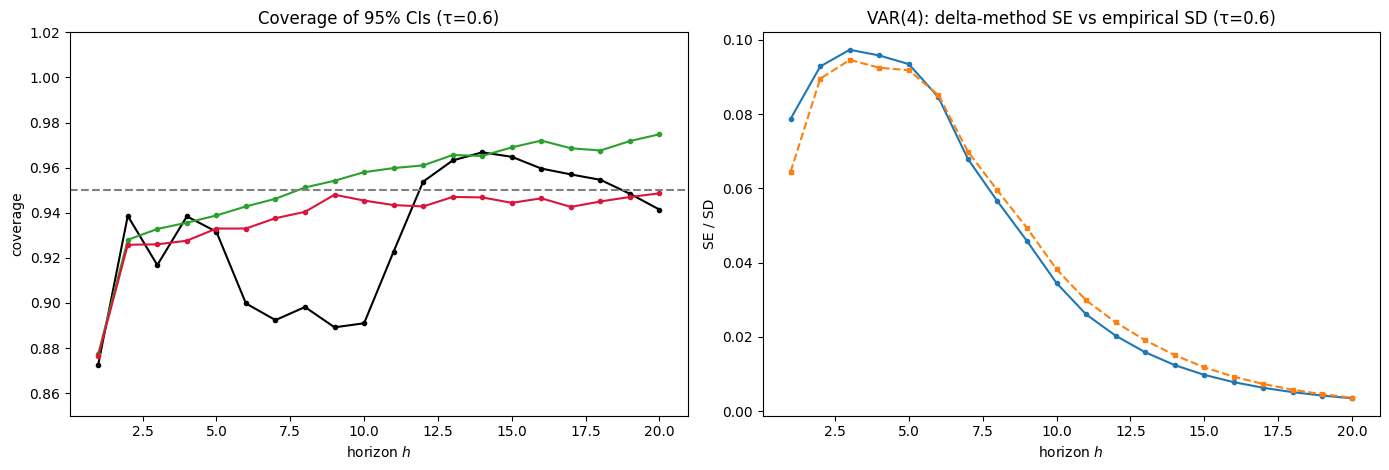

horizon-averaged coverage (h=1..20, τ=0.6):  VAR(4)=0.930   VAR(23)=0.952   LP(4)=0.937


In [8]:
from joblib import Parallel, delayed
from tqdm import tqdm
from mcsim.coverage import var_theta_se, lp_theta_se

T_COV = T_SHOW         # one sample-size cell (Ch. 3 would sweep T as in section 2)
N_COV = 5000           # replications for the coverage MC
Z = 1.96               # normal critical value for a nominal 95% two-sided CI
TAU_COV = 0.6          # fixed at the strongest misspecification (matches the point-estimation panel)
EST_COV = ["VAR(4)", "VAR(23)", "LP(4)"]   # same estimator set as the baseline coverage figure


def _coverage_rep(seed, spec):
    """One replication: simulate from the VARMA spec, return {estimator: (theta_hat, se)}."""
    rng = np.random.default_rng(seed)
    y = simulate_varma(spec, T_COV, rng)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return {"VAR(4)":  var_theta_se(y, 4, H),
                "VAR(23)": var_theta_se(y, 23, H),
                "LP(4)":   lp_theta_se(y, 4, H)}


truth = truth_byTau[TAU_COV]                              # estimand at the fixed misspecification
# Independent, reproducible RNG stream per replication (parallel-safe), as in mcsim.run.
seeds = np.random.SeedSequence(SEED).spawn(N_COV)
reps = Parallel(n_jobs=-1)(delayed(_coverage_rep)(s, DGPS[TAU_COV])
                           for s in tqdm(seeds, desc=f"coverage MC τ={TAU_COV}"))
theta_s = {nm: np.array([r[nm][0] for r in reps]) for nm in EST_COV}
se_s = {nm: np.array([r[nm][1] for r in reps]) for nm in EST_COV}

# Coverage_h = fraction of CIs [theta_hat +/- Z*se] that contain the TRUE theta_h.
coverage = {nm: np.nanmean((theta_s[nm] - Z * se_s[nm] <= truth) &
                           (truth <= theta_s[nm] + Z * se_s[nm]), axis=0) for nm in EST_COV}

# --- Validation: VAR(4) delta-method SE should match the empirical sampling SD ----
val_emp = np.nanstd(theta_s["VAR(4)"], axis=0, ddof=1)
val_se = np.nanmean(se_s["VAR(4)"], axis=0)

fig, (axc, axv) = plt.subplots(1, 2, figsize=(14, 4.8))
cc = {"VAR(4)": "black", "VAR(23)": "tab:green", "LP(4)": "crimson"}
_ylo = float(max(0.0, np.floor((min(np.nanmin(coverage[nm][1:]) for nm in EST_COV) - 0.02) * 20) / 20))
for nm in EST_COV:
    axc.plot(hgrid[1:], coverage[nm][1:], "o-", ms=3, color=cc[nm], label=nm)
axc.axhline(0.95, color="gray", ls="--", label="nominal 0.95")
axc.set_ylim(_ylo, 1.02); axc.set_xlabel("horizon $h$"); axc.set_ylabel("coverage")
axc.set_title(f"Coverage of 95% CIs (τ={TAU_COV})")

axv.plot(hgrid[1:], val_emp[1:], "o-", ms=3, label="empirical SD of $\\hat\\theta_h$")
axv.plot(hgrid[1:], val_se[1:], "s--", ms=3, label="mean delta-method SE")
axv.set_xlabel("horizon $h$"); axv.set_ylabel("SE / SD")
axv.set_title(f"VAR(4): delta-method SE vs empirical SD (τ={TAU_COV})")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_COVERAGE_rho={RHO}_T{T_SHOW}_B=5000.png")
plt.show()

print(f"horizon-averaged coverage (h=1..{H}, τ={TAU_COV}):  " +
      "   ".join(f"{nm}={np.nanmean(coverage[nm][1:]):.3f}" for nm in EST_COV))